In [7]:
import torch
import numpy as np
from copy import deepcopy
import pickle as pkl

from torch import nn
from umap import UMAP

from run_sim import Config, run_sim, run_sim_wrapper, create_data
from utils import *
from utils_plot import *
from tqdm import tqdm
from utils import *
from functools import reduce
import os
from joblib import Parallel, delayed
import shutil


In [8]:
def calc_h_var(G, D, N, L, sig_X):
    return G**(2*L)*(2*D*sig_X)/(D+N)

In [9]:
C = Config()

C.G = 0.5
C.linear_net = False
C.learning_rate = 0.0001
C.L=2
C.print_progress = True
C.length_corridors = [50]*1
C.max_move = C.length_corridors[0]//2
C.hidden_size = 100
C.num_epochs = 10000
C.algo_name = 'Adam'
C.loss_fn = nn.CrossEntropyLoss()
C.bias = True
C.cyclic_corridors = True

# var_name = 'G'
# var_values = [0.1, 1, 10]
var_name = 'max_move'
var_values = np.arange(1, (C.length_corridors[0]-1)//4)#[1, C.length_corridors[0]//2, C.length_corridors[0]-1] # [1, C.length_corridors[0]//4, C.length_corridors[0]//2, 3*C.length_corridors[0]//4, C.length_corridors[0]-1] # np.arange(C.length_corridors[0]) #  
# var_name = 'L'
# var_values = np.arange(8)
# var_values = np.arange(6, 16)

In [10]:


# Ensure the results directory exists
results_dir = f'results/notebook_results/{var_name}'
if os.path.exists(results_dir):
    shutil.rmtree(results_dir)
os.makedirs(results_dir, exist_ok=True)

def run_and_save(var_value):
    C_local = deepcopy(C)
    setattr(C_local, var_name, var_value)
    if var_name == 'L':
        C_local.learning_rate = C.learning_rate * 0.3**C_local.L
    data_dict = run_sim_wrapper(C_local)
    out_path = os.path.join(results_dir, f'data_dict_{getattr(C_local, var_name)}.pkl')
    with open(out_path, 'wb') as f:
        pkl.dump(data_dict, f)
    return out_path

# Run in parallel
paths = Parallel(n_jobs=-1)(
    delayed(run_and_save)(var_value) for var_value in var_values
)
# Load all results into data_dict_l
data_dict_l = []
for path in paths:
    with open(path, 'rb') as f:
        data_dict_l.append(pkl.load(f))

for data_dict in data_dict_l:
    print(f'{var_name}: {getattr(data_dict["C"], var_name)} --- X shape: {data_dict["X"].shape} --- Number of hidden: {data_dict["C"].hidden_size}')

Number of samples: 1050
Input dimension: 71
Output dimension: 50
Number of actions: 21

Number of samples: 350
Input dimension: 57
Output dimension: 50
Number of actions: 7

Number of samples: 1150
Input dimension: 73
Output dimension: 50
Number of actions: 23

Number of samples: 150
Input dimension: 53
Output dimension: 50
Number of actions: 3

Number of samples: 850
Input dimension: 67
Output dimension: 50
Number of actions: 17

Number of samples: 550
Input dimension: 61
Output dimension: 50
Number of actions: 11

Number of samples: 950
Input dimension: 69
Output dimension: 50
Number of actions: 19

Number of samples: 650
Input dimension: 63
Output dimension: 50
Number of actions: 13

Number of samples: 450
Input dimension: 59
Output dimension: 50
Number of actions: 9

Number of samples: 250
Input dimension: 55
Output dimension: 50
Number of actions: 5

Number of samples: 750
Input dimension: 65
Output dimension: 50
Number of actions: 15

Variance of last hidden: 2.01e-03, of output:

  2%|▏         | 197/10000 [00:00<00:27, 356.34it/s]

Variance of last hidden: 1.82e-03, of output: 7.03e-03
Variance of last hidden: 2.84e-03, of output: 7.96e-03
Variance of last hidden: 2.56e-03, of output: 8.43e-03
Variance of last hidden: 2.42e-03, of output: 8.57e-03
Variance of last hidden: 2.81e-03, of output: 1.06e-02
Variance of last hidden: 2.12e-03, of output: 7.88e-03


  3%|▎         | 281/10000 [00:01<00:29, 327.41it/s]

Variance of last hidden: 2.75e-03, of output: 1.08e-02
Variance of last hidden: 2.19e-03, of output: 6.75e-03


  4%|▍         | 376/10000 [00:01<00:24, 393.96it/s]

Variance of last hidden: 2.99e-03, of output: 7.64e-03
Variance of last hidden: 2.77e-03, of output: 8.62e-03


100%|██████████| 10000/10000 [03:10<00:00, 52.62it/s]


max_move: 1 --- X shape: torch.Size([150, 53]) --- Number of hidden: 100
max_move: 2 --- X shape: torch.Size([250, 55]) --- Number of hidden: 100
max_move: 3 --- X shape: torch.Size([350, 57]) --- Number of hidden: 100
max_move: 4 --- X shape: torch.Size([450, 59]) --- Number of hidden: 100
max_move: 5 --- X shape: torch.Size([550, 61]) --- Number of hidden: 100
max_move: 6 --- X shape: torch.Size([650, 63]) --- Number of hidden: 100
max_move: 7 --- X shape: torch.Size([750, 65]) --- Number of hidden: 100
max_move: 8 --- X shape: torch.Size([850, 67]) --- Number of hidden: 100
max_move: 9 --- X shape: torch.Size([950, 69]) --- Number of hidden: 100
max_move: 10 --- X shape: torch.Size([1050, 71]) --- Number of hidden: 100
max_move: 11 --- X shape: torch.Size([1150, 73]) --- Number of hidden: 100


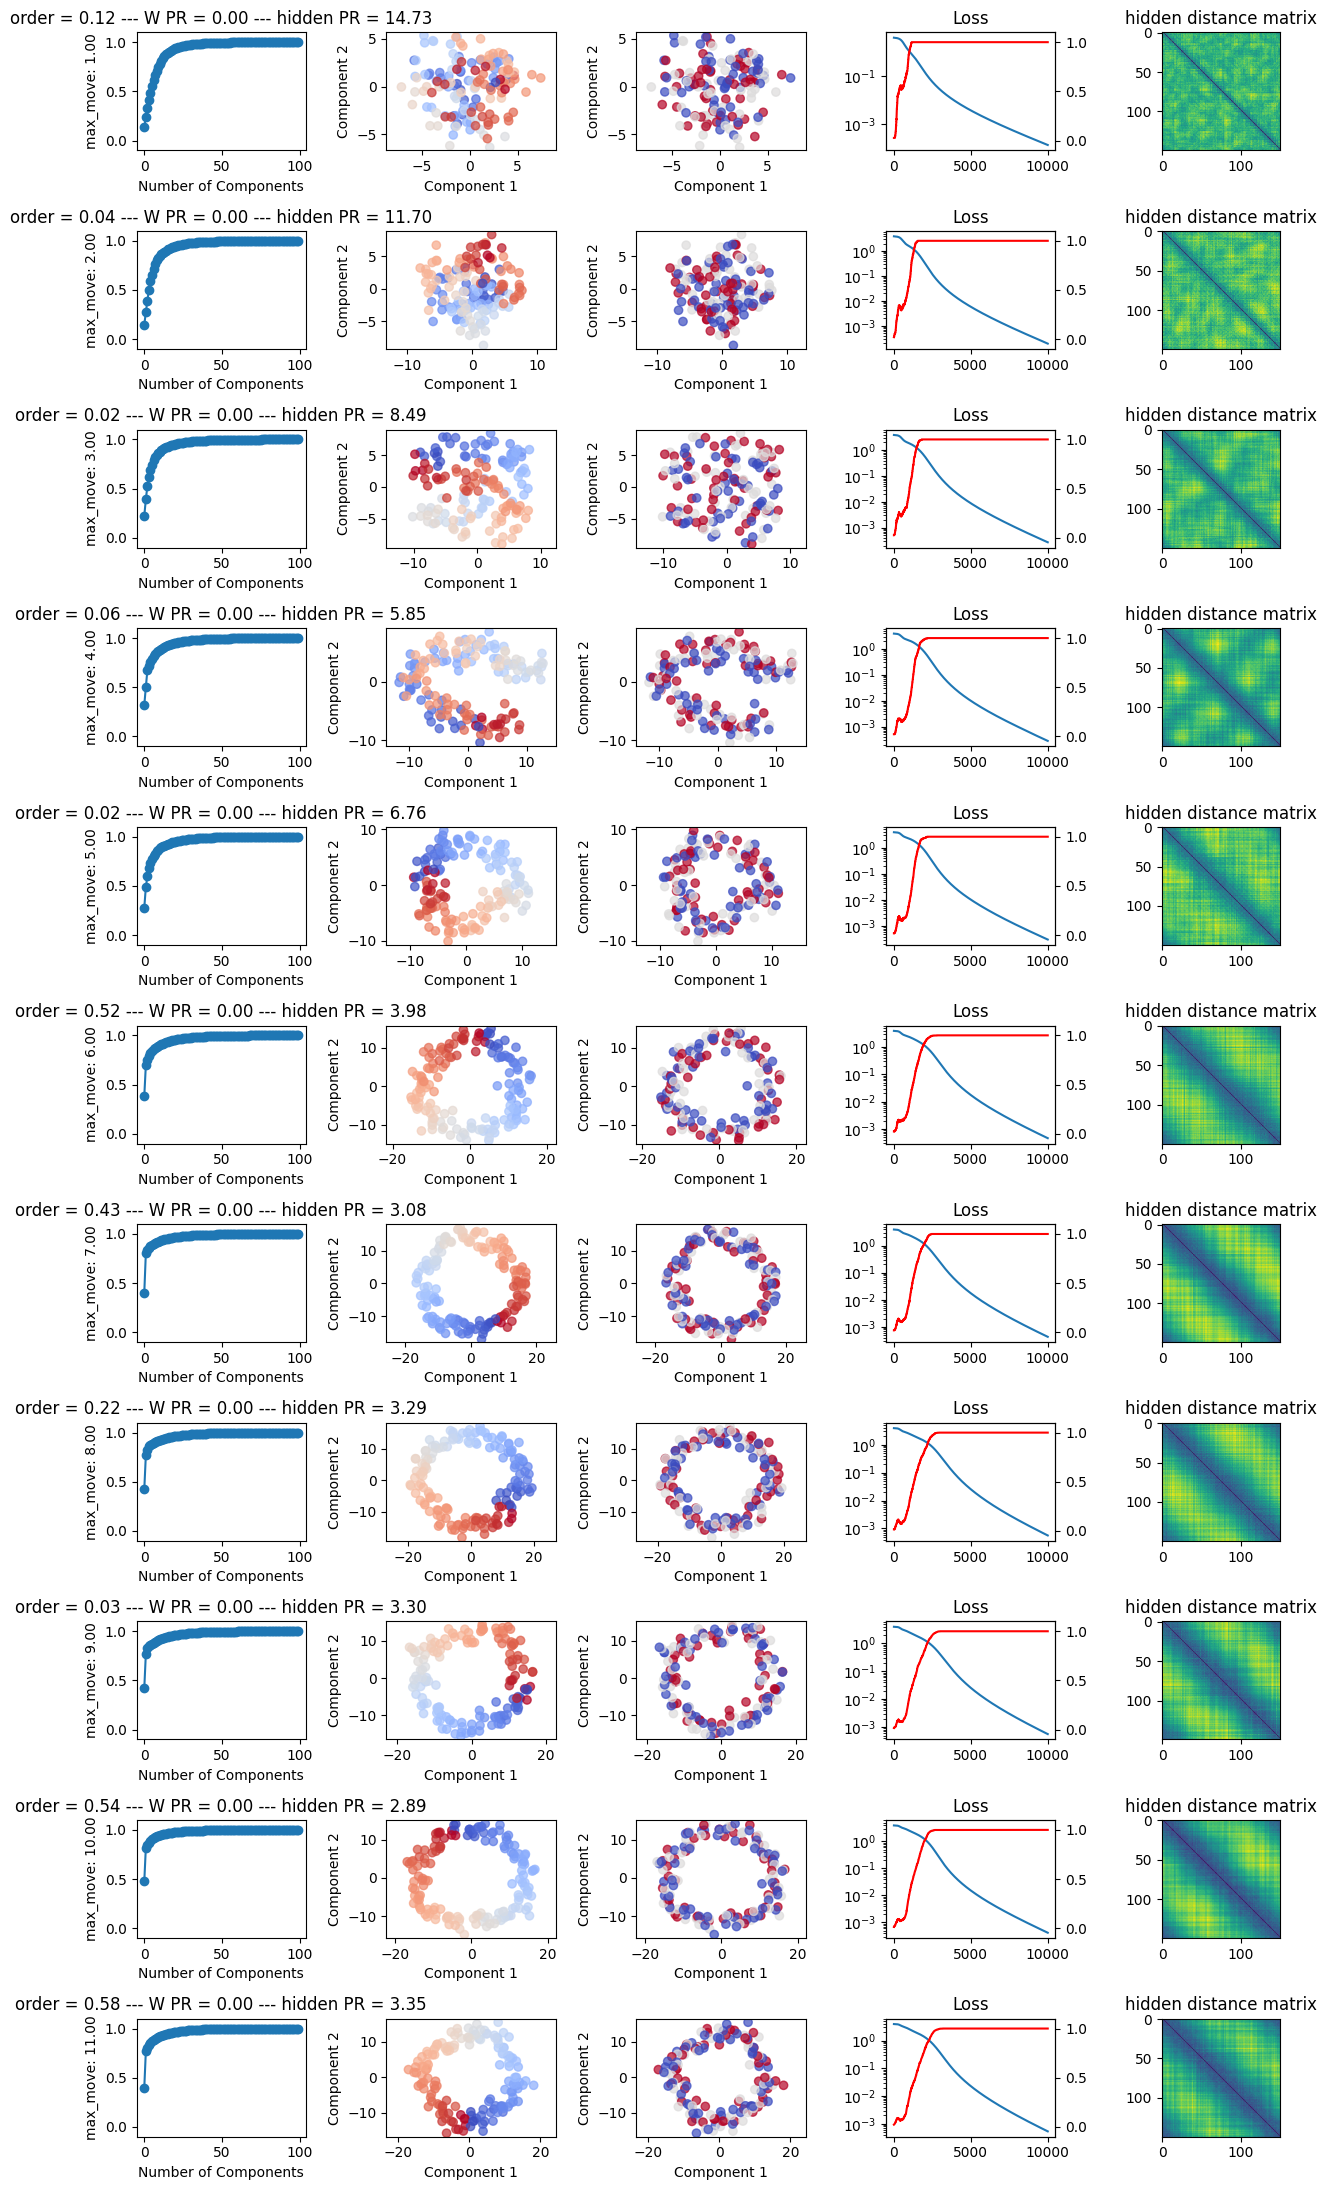

In [11]:
fig, axs = plt.subplots(len(data_dict_l), 5, figsize=(25/2, len(data_dict_l)*4/2))
for data_dict, axs_current in zip(data_dict_l, axs):
    plot_pca(data_dict, axs=axs_current)
    axs_current[0].set_ylabel(f'{var_name}: {getattr(data_dict["C"], var_name):.2f}')

In [12]:
stop

NameError: name 'stop' is not defined

In [ ]:

def multiclass_functional_margin(W, X, y, reducer=np.min, normalize=True):
    if normalize:
        W = W / np.linalg.norm(W)
    margins = []
    all_margins = []
    i_max_other_score_l = []
    for x, y_curr in zip(X, y):
        label = y_curr.argmax()
        scores = x@W  # shape (K,)
        true_score = scores[label]
        max_other_score = np.max(np.delete(scores, label))
        i_max_other_score = np.argmax(np.delete(scores, label))
        margins.append(true_score - max_other_score)
        all_margins.append(true_score - np.delete(scores, label))
    return reducer(margins), np.array(all_margins)



max_move_l = var_values
margins_l = []
for data_dict in data_dict_l:
    # Compute all margins first to determine common bins
    X = data_dict['X'].cpu().numpy()
    y = data_dict['y'].cpu().numpy()
    labels = y.argmax(1)
    W = get_effective_W_from_model_dict(data_dict['final_weights']).cpu().numpy()
    margins, all_margins = multiclass_functional_margin(W, X, y, reducer=np.array, normalize=False)
    W_rec = np.stack([X[margins[labels==i].argmin()] for i in np.unique(labels)])
    margins_l.append(margins)
# Concatenate all margins to get global min/max
all_margins_concat = np.concatenate(margins_l)
# Choose bins (e.g., 20 bins between min and max)
n_bins = 100
bins = np.linspace(all_margins_concat.min(), all_margins_concat.max(), n_bins + 1)

fig, axs = plt.subplots(2, 1, figsize=(10, 5), sharex=True, sharey=True)
for ax, margins, max_move in zip(axs, margins_l, max_move_l):
    ax.hist(margins, bins=bins, alpha=1, density=True)
    ax.set_title(f'A={max_move}')
ax.set_xlabel('sample margins')
plt.show()

In [ ]:
PR_S_l = []
PR_W_l = []
NC1_l = []
for data_dict in data_dict_l:
    X = data_dict['X'].cpu().numpy()
    y = data_dict['y'].cpu().numpy()
    Sigma11 = np.array(X.T@X, dtype=np.float64)
    Sigma31 = np.array(X.T@y, dtype=np.float64)
    W = get_effective_W_from_model_dict(data_dict['final_weights']).cpu().numpy()
    Sigma = np.linalg.pinv(Sigma11)@Sigma31
    PR_S_l.append(calc_PR(Sigma))
    PR_W_l.append(calc_PR(W))
    NC1_l.append(calc_NC1(X@W, y.argmax(1)))

/home/avivra/Desktop/project/RepresentationShaping/utils.py:667: UserWarning: The use of `x.T` on tensors of dimension other than 2 to reverse their shape is deprecated and it will throw an error in a future release. Consider `x.mT` to transpose batches of matrices or `x.permute(*torch.arange(x.ndim - 1, -1, -1))` to reverse the dimensions of a tensor. (Triggered internally at /pytorch/aten/src/ATen/native/TensorShape.cpp:4421.)
  W_effective = W_effective @ W.T


RuntimeError: mat1 and mat2 shapes cannot be multiplied (1x33 and 256x256)

In [ ]:

# plt.plot(var_values, PR_S_l, label='PR_S', marker='o')
plt.scatter(PR_S_l, PR_W_l, label='PR_W', marker='o')
plt.scatter(PR_S_l, NC1_l, label='NC1', marker='o')
plt.legend()
plt.yscale('log')
plt.xscale('log')
plt.xlabel('PR_S')
plt.show()

In [ ]:
fig, axs_all = plt.subplots(len(data_dict_l), 7, figsize=(20, 3*len(data_dict_l)))
for data_dict, axs in zip(data_dict_l, axs_all):
    X = data_dict['X'].cpu().numpy()
    y = data_dict['y'].cpu().numpy()
    corridor = data_dict['corridor']
    Sigma11 = np.array(X.T@X, dtype=np.float64)
    Sigma31 = np.array(y.T@X, dtype=np.float64)
    W = get_effective_W_from_model_dict(data_dict['final_weights']).cpu().numpy()
    U, S, V = np.linalg.svd(Sigma31@np.linalg.pinv(Sigma11), full_matrices=False)
    print(f'X shape: {X.shape} --- U shape: {U.shape} --- V shape: {V.shape}')

    rank = 2
    axs[0].plot(U[:, :rank])
    axs[0].set_title('U data')
    axs[1].plot(S, marker='o')
    axs[1].set_title('S data')
    axs[2].plot(V[:rank].T)
    axs[2].set_title('V data')

    U, S, V = np.linalg.svd(W, full_matrices=False)
    axs[3].plot(U[:, :rank])
    axs[3].set_title('U model')
    axs[4].plot(S, marker='o')
    axs[4].set_title('S model')
    axs[5].plot(V[:rank].T)
    axs[5].set_title('V model')
    plt.tight_layout()
    

    W_corr = Sigma31@np.linalg.pinv(Sigma11)
    U, S, V = np.linalg.svd(W_corr.T, full_matrices=False)
    for cor, marker in zip(np.unique(corridor), markers):
        axs[-1].scatter(X[corridor==cor]@U[:, 0], X[corridor==cor]@U[:, 1], c=y[corridor==cor].argmax(1), marker=marker)
    axs[-1].set_title(f'accuracy: {calc_accuracy_from_W(W_corr.T, X, y):.2f}')
    axs[-1].axis('equal')
plt.show()

In [ ]:
for data_dict in data_dict_l:
    print(data_dict['accuracy_l'][-1])
    print(1899/1900)

In [ ]:
max_move_l = var_values[::2]
margins_l = []
for data_dict in data_dict_l[::2]:
    # Compute all margins first to determine common bins
    X = data_dict['X'].cpu().numpy()
    y = data_dict['y'].cpu().numpy()
    loc_X = data_dict['loc_X']
    labels = y.argmax(1)
    W = get_effective_W_from_model_dict(data_dict['final_weights']).cpu().numpy()
    margins, all_margins = multiclass_functional_margin(W, X, y, reducer=np.array, normalize=False)
    inds = margins.argsort()[:20]
    plt.scatter(loc_X[inds], margins[inds])
    plt.show()

In [ ]:
plt.imshow(W.T)
plt.show()
plt.imshow(W_rec.T)

In [ ]:

X = data_dict_l[0]['X'].cpu().numpy()
y = data_dict_l[0]['y'].cpu().numpy()
fig, ax = plt.subplots(1, 1, figsize=(6*1.5, 8/2))
for data_dict in data_dict_l:
    W = get_effective_W_from_model_dict(data_dict['final_weights']).cpu().numpy()
    S = data_dict['C'].length_corridors[0]
    A = data_dict['C'].max_move
    W = np.delete(W, np.concatenate([np.arange(S+A-1, S+A-1+A), np.arange(S+A+2, S+2*A+1)]), axis=0)
    margins, _, _ = multiclass_functional_margin(W, X, y, reducer=np.array)
    ax.hist(margins, label=f'{var_name}: {getattr(data_dict["C"], var_name):.2f}', alpha=0.8)
ax.set_xlim(0)
ax.legend()
plt.show()

In [ ]:
def calc_metrics(data_dict, i=-1):
    hidden = data_dict['hidden_states'][i].cpu().detach().numpy()
    PR = calc_PR(hidden)
    loc_y = data_dict['loc_y']
    corridor = data_dict['corridor']
    order = np.mean([get_r_2(PCA(n_components=1).fit_transform(hidden[corridor==cor]), loc_y[corridor==cor]) for cor in np.unique(corridor)])
    alignment = np.mean(alignment_score(hidden[corridor==0], hidden[corridor==1]))
    return PR, order, alignment

In [ ]:
PR_l = []
order_l = []
alignment_l = []
for data_dict in data_dict_l:
    PR, order, alignment = calc_metrics(data_dict)
    PR_l.append(1/PR)
    order_l.append(order)
    alignment_l.append(alignment)
plt.plot(var_values, order_l, label='order', marker='o')   
plt.plot(var_values, alignment_l, label='alignment', marker='o')
plt.plot(var_values, PR_l, label='1/PR', marker='o', c='tab:green')
plt.legend()
plt.xlabel(var_name)
plt.ylim(0)
plt.axhline(1, color='gray', linestyle='--', alpha=0.5)
plt.show()

In [ ]:
fig, axs = plt.subplots(len(data_dict_l), 3, figsize=(15, 10))
for i, data_dict in enumerate(data_dict_l):
    X = data_dict['X'].cpu().numpy()
    y = data_dict['y'].cpu().numpy()
    corridor = data_dict['corridor']
    W = get_effective_W_from_model_dict(data_dict['final_weights']).cpu().numpy()
    
    Sigma11 = np.array(X.T@X, dtype=np.float64)
    Sigma31 = np.array(y.T@X, dtype=np.float64)
    axs[i, 0].imshow(W.T)
    axs[i, 1].imshow(Sigma31@np.linalg.pinv(Sigma11))

    US, SS, VS = np.linalg.svd(Sigma31@np.linalg.pinv(Sigma11), full_matrices=False)
    UW, SW, VW = np.linalg.svd(W.T, full_matrices=False)
    print(UW.shape, VW.shape)
    print(US.shape, SS.shape, VS.shape)
    axs[i, 2].imshow(abs(VW@VS.T))

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(10, 5))
for i, data_dict in enumerate(data_dict_l):
    X = data_dict['X'].cpu().numpy()
    y = data_dict['y'].cpu().numpy()
    corridor = data_dict['corridor']
    W = get_effective_W_from_model_dict(data_dict['final_weights']).cpu().numpy()
    
    U, S, V = np.linalg.svd(W, full_matrices=False)
    accuracy_l = []
    for n in range(1, U.shape[1]):
        out = X@U[:,:n]@np.diag(S[:n])@V[:n,:]
        accuracy_l.append((out.argmax(1) == y.argmax(1)).mean())
    ax.plot(accuracy_l, label=f'{var_name}: {getattr(data_dict["C"], var_name):.2f}', marker='o')
    print(accuracy_l[-1])
ax.axhline(1, color='gray', linestyle='--', alpha=0.5)
ax.legend()
plt.show()


In [ ]:
for data_dict in data_dict_l:
    X = data_dict['X'].cpu().numpy()
    y = data_dict['y'].cpu().numpy()
    corridor = data_dict['corridor']
    Sigma11 = np.array(X.T@X, dtype=np.float64)
    Sigma31 = np.array(y.T@X, dtype=np.float64)
    W = get_effective_W_from_model_dict(data_dict['final_weights']).cpu().numpy()
    U, S, V = np.linalg.svd(Sigma31@np.linalg.pinv(Sigma11), full_matrices=False)
    print(f'X shape: {X.shape} --- U shape: {U.shape} --- V shape: {V.shape}')
    fig, axs = plt.subplots(1, 7, figsize=(20, 3))
    rank = 2
    axs[0].plot(U[:, :rank])
    axs[0].set_title('U data')
    axs[1].plot(S, marker='o')
    axs[1].set_title('S data')
    axs[2].plot(V[:rank].T)
    axs[2].set_title('V data')

    U, S, V = np.linalg.svd(W, full_matrices=False)
    axs[3].plot(U[:, :rank])
    axs[3].set_title('U model')
    axs[4].plot(S, marker='o')
    axs[4].set_title('S model')
    axs[5].plot(V[:rank].T)
    axs[5].set_title('V model')
    plt.tight_layout()
    

    W_corr = Sigma31@np.linalg.pinv(Sigma11)
    U, S, V = np.linalg.svd(W_corr.T, full_matrices=False)
    for cor, marker in zip(np.unique(corridor), markers):
        axs[-1].scatter(X[corridor==cor]@U[:, 0], X[corridor==cor]@U[:, 1], c=y[corridor==cor].argmax(1), marker=marker)
    axs[-1].set_title(f'accuracy: {calc_accuracy_from_W(W_corr.T, X, y):.2f}')
    axs[-1].axis('equal')
    plt.show()

In [ ]:
for data_dict in data_dict_l:
    X = data_dict['X'].cpu().numpy()
    y = data_dict['y'].cpu().numpy()
    Sigma11 = X.T@X
    Sigma31 = y.T@X
    US, SS, VS = np.linalg.svd(Sigma31@np.linalg.pinv(Sigma11), full_matrices=False)
    sim_l = []
    for state_dict in data_dict['state_dict_l']:
        W = get_effective_W_from_model_dict(state_dict).cpu().numpy()
        UW, SW, VW = np.linalg.svd(W, full_matrices=False)
        sim_l.append(cosine_similarity(UW[:, 2], VS[2]))
    plt.plot(sim_l)
        # print(W.shape, (Sigma31@np.linalg.pinv(Sigma11)).shape)
        # print(UW.shape, VS.shape)
        # plt.imshow(abs(UW.T@VS.T))
        # plt.show()
    fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(10, 5))
    ax1.imshow(W.T)
    ax1.set_title('W')
    ax2.imshow(Sigma31@np.linalg.pinv(Sigma11))
    ax2.set_title('Sigma31@np.linalg.pinv(Sigma11)')
    rank = 4
    ax3.imshow(US[:,:rank]@np.diag(SS[:rank])@VS[:rank,:])
    ax3.set_title('rank 2 approximation of Sigma31@np.linalg.pinv(Sigma11)')
    plt.tight_layout()
    plt.show()

In [ ]:
W1 = get_effective_W_from_model_dict(data_dict_l[0]['final_weights']).cpu().numpy()
Win = data_dict_l[1]['final_weights']['input_layer.weight'].cpu().numpy().T
X = data_dict_l[1]['X'].cpu().numpy()
U, S, V = np.linalg.svd(W1)
U1, S1, V1 = np.linalg.svd(Win)
plt.plot(U[:,0])
plt.gca().twinx().plot(U1[:, 0], c='r')
plt.show()

In [ ]:
fig1, axs1 = plt.subplots(1, len(data_dict_l), figsize=(12, 4))
fig2, axs2 = plt.subplots(1, len(data_dict_l), figsize=(12, 4))
for i, data_dict in enumerate(data_dict_l):
    X = data_dict['X'].cpu().numpy()
    y = data_dict['y'].cpu().numpy().argmax(1)
    W = get_effective_W_from_model_dict(data_dict['final_weights']).cpu().numpy()
    action_taken = data_dict['action_taken']
    loc_X = data_dict['loc_X']
    loc_y = data_dict['loc_y']
    cond = abs(action_taken) <= 1
    # X = X[cond]; y = y[cond]; action_taken = action_taken[cond]; loc_X = loc_X[cond]; loc_y = loc_y[cond]
    # W /= np.linalg.norm(W)
    scores = X@W
    losses = torch.nn.functional.cross_entropy(torch.from_numpy(scores), torch.from_numpy(y), reduction='none').numpy()
    true_scores = scores[np.arange(len(scores)), y]
    scores[np.arange(len(scores)), y] = 0
    margins = (true_scores[:,None] - scores).max(1)
    # 2D histogram: y-axis is action_taken, x-axis is loc_X, values are margins
    plt.figure(figsize=(8, 6))
    # Ensure action_taken and loc_X are 1D arrays
    action_taken_arr = np.array(action_taken).flatten()
    loc_X_arr = np.array(loc_X).flatten()
    # Use np.histogram2d to bin the data, weighting by margins
    bins_x = np.unique(loc_X_arr)
    bins_y = np.unique(action_taken_arr)
    # Add 1 to bins for histogram2d edges
    x_edges = np.arange(bins_x.min(), bins_x.max() + 2) - 0.5
    y_edges = np.arange(bins_y.min(), bins_y.max() + 2) - 0.5
    for var, name, axs in zip([losses, margins], ['losses', 'margins'], [axs1, axs2]):
        hist, xedges, yedges = np.histogram2d(
            loc_X_arr, action_taken_arr, bins=[x_edges, y_edges], weights=np.log10(var)
        )
        # Normalize by counts to get mean margin per bin
        counts, _, _ = np.histogram2d(
            loc_X_arr, action_taken_arr, bins=[x_edges, y_edges]
        )
        mean_margins = np.divide(hist, counts, out=np.zeros_like(hist), where=counts!=0)
        mean_margins[mean_margins==0] = np.nan
        # Plot with imshow (transpose for correct orientation)
        axs[i].imshow(
            mean_margins.T,
            aspect='auto',
            origin='lower',
            extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]],
            cmap='viridis'
        )   
        axs[i].axis('equal')
        axs[i].set_xlabel('loc_X')
        axs[i].set_ylabel('action_taken')
        axs[i].scatter(np.arange(mean_margins.shape[0]),np.nanargmin(mean_margins, 1)-1, c='red')
fig1.suptitle('losses')
fig2.suptitle('margins')

In [ ]:
mean_margins.argmin(1)

In [ ]:
fig, axs = plt.subplots(1, len(data_dict_l), figsize=(16, 4))
fig2, axs2 = plt.subplots(1, len(data_dict_l), figsize=(16, 4))
for i, data_dict in enumerate(data_dict_l):
    X = data_dict['X'].cpu().numpy()
    y = data_dict['y'].cpu().numpy().argmax(1)
    W = get_effective_W_from_model_dict(data_dict['final_weights']).cpu().numpy()
    action_taken = data_dict['action_taken']
    loc_X = data_dict['loc_X']+1
    loc_y = data_dict['loc_y']+1
    cond = abs(action_taken) <= 1
    # X = X[cond]; y = y[cond]; action_taken = action_taken[cond]; loc_X = loc_X[cond]; loc_y = loc_y[cond]
    # W /= np.linalg.norm(W)
    scores = X@W
    losses = torch.nn.functional.cross_entropy(torch.from_numpy(scores), torch.from_numpy(y), reduction='none').numpy()
    true_scores = scores[np.arange(len(scores)), y]
    scores[np.arange(len(scores)), y] = -np.inf
    margins = (true_scores[:,None] - scores).min(1)
    sc = axs[i].scatter(loc_y, margins, c=action_taken, cmap='berlin')
    plt.colorbar(sc, ax=axs[i], label='action_taken')
    [axs[i].axvline(x=x, color='black', ls='--', alpha=0.2) for x in np.unique(loc_X)]
    txt = ' --- '.join([f'{loc_y[i]} with {scores[i].argmax()+1}' for i in margins.argsort()[:2]])
    axs[i].set_title(txt)

    sc = axs2[i].scatter(loc_y, losses, c=action_taken, cmap='berlin')
    plt.colorbar(sc, ax=axs2[i], label='action_taken')
    [axs2[i].axvline(x=x, color='black', ls='--', alpha=0.2) for x in np.unique(loc_X)]
    txt = ' --- '.join([f'{loc_y[i]} with {scores[i].argmax()+1}' for i in losses.argsort()[-2:]])
    axs2[i].set_title(txt)


In [ ]:
loss_l = []
loss_rec_l = []
for data_dict in data_dict_l:
    X = data_dict['X'].cpu().numpy()
    y = data_dict['y'].cpu().numpy().argmax(1)
    W = get_effective_W_from_model_dict(data_dict['final_weights']).cpu().numpy()

    action_taken = data_dict['action_taken']
    loc_X = data_dict['loc_X']
    loc_y = data_dict['loc_y']
    n_classes = len(np.unique(y))
    cond = abs(action_taken) <= 1
    bool_arr = np.concatenate([np.ones(n_classes, dtype=bool), abs(np.unique(action_taken))<=1])
    X = X[cond]; y = y[cond]; action_taken = action_taken[cond]; loc_X = loc_X[cond]; loc_y = loc_y[cond]
    X = X[:, bool_arr]
    W = W[bool_arr, :]
    W = W/np.linalg.norm(W)
    U, S, V = np.linalg.svd(W)
    rank = 10
    pca = X@U[:,:rank]@np.diag(S[:rank])@V[:rank,:]
    # plt.scatter(pca[:,0], pca[:,1], c=y)
    # plt.axis('equal')
    # plt.show()
    plt.plot(U[:,0])
#     loss_l.append(torch.nn.functional.cross_entropy(torch.from_numpy(pca), torch.from_numpy(y)))
#     loss_rec_l.append(torch.nn.functional.cross_entropy(torch.from_numpy(X@W), torch.from_numpy(y)))
# loss_l = np.array(loss_l)
# loss_rec_l = np.array(loss_rec_l)
# loss_l -= loss_l.min()
# loss_rec_l -= loss_rec_l.min()
# loss_l /= loss_l.max()
# loss_rec_l /= loss_rec_l.max()
# plt.plot(loss_l, label='pca')
# plt.plot(loss_rec_l, label='rec')
# plt.legend()
# plt.show()

In [ ]:
import numpy as np
import cvxpy as cp
fig, axs = plt.subplots(1, len(data_dict_l), figsize=(16, 4))
fig2, axs2 = plt.subplots(1, len(data_dict_l), figsize=(16, 4))
W_LP_l = []
for j, d in enumerate(data_dict_l):
    action_taken = d['action_taken']
    X = d['X'].cpu().numpy()[abs(action_taken) <= 1]
    y = d['y'].cpu().numpy()[abs(action_taken) <= 1]
    loc_y = d['loc_y']
    loc_X = d['loc_X']
    action_taken = d['action_taken']
    labels = y.argmax(1)
    y = y.argmax(1)

    n_samples, n_features = X.shape
    n_classes = np.unique(labels).size

    # Define variables: weight vector for each class
    W_LP = cp.Variable((n_classes, n_features))

    # Constraints: for each sample i and each incorrect class k ≠ y_i,
    # enforce: (w_{y_i} - w_k) ⋅ x_i ≥ 1
    constraints = []
    for i in range(n_samples):
        xi = X[i]
        yi = labels[i]
        for k in range(n_classes):
            if k == yi:
                continue
            constraint = (W_LP[yi] - W_LP[k]) @ xi >= 1
            constraints.append(constraint)
    
    random_direction = np.random.randn(n_classes, n_features).T
    random_direction = random_direction / np.linalg.norm(random_direction)
    objective = cp.Maximize(0)

    prob = cp.Problem(objective, constraints)
    prob.solve()

    # Print results
    if prob.status == "optimal" or prob.status == "optimal_inaccurate":
        print("Feasible point found.")
    else:
        print("No feasible point found.")
        print(prob.status)
    W = W_LP.value.T
    # W /= np.linalg.norm(W)
    U, S, V = np.linalg.svd(W)
    rank = 2
    pca = X@U[:,:rank]@np.diag(S[:rank])@V[:rank,:]
    axs[j].scatter(pca[:,0], pca[:,1], c=labels)
    # axs[j].plot(W)
    axs[j].axis('equal')
    # Calculate minimal margins for each sample
    margins = []
    for i in range(n_samples):
        true_class = labels[i]
        x_i = X[i]
        # Compute margins to all other classes
        margins_i = []
        for k in range(n_classes):
            if k == true_class:
                continue
            margin = (W[:, true_class] - W[:, k]) @ x_i
            margins_i.append(margin)
        margins.append(min(margins_i))
    min_margin = np.min(margins)
    # axs[j].set_title(f'Min margin: {min_margin:.3f}, accuracy: {((X@W).argmax(1)==labels).mean():.3f}')
    
    # scores = X@W
    # losses = torch.nn.functional.cross_entropy(torch.from_numpy(scores), torch.from_numpy(y), reduction='none').numpy()
    # true_scores = scores[np.arange(len(scores)), y]
    # scores[np.arange(len(scores)), y] = -np.inf
    # margins = (true_scores[:,None] - scores).min(1)
    # sc = axs[j].scatter(loc_y, margins, c=action_taken, cmap='berlin')
    # plt.colorbar(sc, ax=axs[j], label='action_taken')
    # [axs[j].axvline(x=x, color='black', ls='--', alpha=0.2) for x in np.unique(loc_X)]
    # txt = ' --- '.join([f'{loc_y[i]} with {scores[i].argmax()+1}' for i in margins.argsort()[:2]])
    # axs[j].set_title(txt)

    # sc = axs2[j].scatter(loc_y, losses, c=action_taken, cmap='berlin')
    # plt.colorbar(sc, ax=axs2[j], label='action_taken')
    # [axs2[j].axvline(x=x, color='black', ls='--', alpha=0.2) for x in np.unique(loc_X)]
    # txt = ' --- '.join([f'{loc_y[i]} with {scores[i].argmax()+1}' for i in losses.argsort()[-2:]])
    # axs2[j].set_title(txt)


In [ ]:
plt.imshow(W)

In [ ]:
U, S, V = np.linalg.svd(W)
plt.plot(U[:,0])

In [ ]:
for data_dict in data_dict_l:
    # data_dict = data_dict_l[1]
    C = data_dict['C']
    X = data_dict['X'].cpu().numpy()
    y = data_dict['y'].cpu().numpy().argmax(1)
    W = get_effective_W_from_model_dict(data_dict['final_weights'])
    loc_X = data_dict['loc_X']
    loc_y = data_dict['loc_y']
    W = W.cpu().numpy()
    if C.L == 0:
        U, S, V = np.linalg.svd(W, full_matrices=False)
        hidden = X @ U @ np.diag(S)
    else:   
        hidden = data_dict['hidden_states'][-1].cpu().detach().numpy()

    np.linalg.matrix_rank(W, tol=1)

    U, S, V = np.linalg.svd(W, full_matrices=False)
    # plt.plot(U[:,:4], marker='o')
    rank = 2
    accuracy = (((X@U[:,:rank])@np.diag(S[:rank])@V[:rank,:]).argmax(1)==y).mean()
    plt.plot(S, marker='o', label=f'rank {rank} accuracy: {accuracy:.2f}')
plt.legend()
plt.yscale('log')

In [ ]:
from mpl_toolkits.mplot3d import Axes3D

for data_dict in data_dict_l:
    # data_dict = data_dict_l[1]
    C = data_dict['C']
    X = data_dict['X'].cpu().numpy()
    y = data_dict['y'].cpu().numpy().argmax(1)
    W = get_effective_W_from_model_dict(data_dict['final_weights'])
    loc_X = data_dict['loc_X']
    loc_y = data_dict['loc_y']
    W = W.cpu().numpy()
    if C.L == 0:
        U, S, V = np.linalg.svd(W, full_matrices=False)
        hidden = X @ U @ np.diag(S)
    else:   
        hidden = data_dict['hidden_states'][-1].cpu().detach().numpy()

    np.linalg.matrix_rank(W, tol=1)

    U, S, V = np.linalg.svd(W, full_matrices=False)
    # plt.plot(U[:,:4], marker='o')
    rank = 3
    hidden = X@U[:,:rank]@np.diag(S[:rank])

    plt.scatter(hidden[:,0], hidden[:,1], c=y, cmap='viridis', marker='o')
    cmap = plt.get_cmap('viridis')
    for i in range(V.shape[0]):
        plt.arrow(0, 0, V[0, i]*100, V[1, i]*100, head_width=10, head_length=10, color=cmap(i/(V.shape[0]-1)))
    plt.axis('equal')
    plt.show()

In [ ]:
data_dict = data_dict_l[2]
C = data_dict['C']
X = data_dict['X'].cpu().numpy()
y = data_dict['y'].cpu().numpy().argmax(1)
W = get_effective_W_from_model_dict(data_dict['final_weights'])
loc_X = data_dict['loc_X']
loc_y = data_dict['loc_y']
W = W.cpu().numpy()
if C.L == 0:
    U, S, V = np.linalg.svd(W, full_matrices=False)
    hidden = X @ U @ np.diag(S)
else:   
    hidden = data_dict['hidden_states'][-1].cpu().detach().numpy()

np.linalg.matrix_rank(W, tol=1)

U, S, V = np.linalg.svd(W, full_matrices=False)
r = 1
W_rec = U[:,:r] @ np.diag(S[:r]) @ V[:r,:]
print(f'Accuracy: {((X@W_rec).argmax(1)==y).mean()}')
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))
ax1.plot(W, marker='o')
ax1.set_title(data_dict['C'].max_move)
ax2.plot(S, marker='o')
plt.show()

plt.plot(data_dict['loc_X'], X[:,:C.length_corridors[0]]@U[:C.length_corridors[0],0]*S[0], marker='o', alpha=0.5)
plt.scatter(data_dict['loc_y'], X@U[:,0]*S[0], marker='o', c='tab:orange')
plt.show()


plt.scatter(X@U[:,0]*S[0], PCA(n_components=1).fit_transform(hidden), marker='o', c=data_dict['loc_y'])
# plt.axis('equal')

In [ ]:
U[:3,:3]

In [ ]:
fig, axs = plt.subplots(2, 3, figsize=(15, 10), sharex='col')
for i, data_dict in enumerate([data_dict_l[0], data_dict_l[1]]):
    C = data_dict['C']
    X = data_dict['X'].cpu().numpy()
    y = data_dict['y'].cpu().numpy().argmax(1)
    W = get_effective_W_from_model_dict(data_dict['final_weights'])
    loc_X = data_dict['loc_X']
    loc_y = data_dict['loc_y']
    action_taken = data_dict['action_taken']
    W = W.cpu().numpy()
    U, S, V = np.linalg.svd(W, full_matrices=False)
    # plt.plot(U[:,0])
    W /= np.linalg.norm(W)
    X_filtered = X[abs(action_taken)==0]
    y_filtered = y[abs(action_taken)==0]
    scores = X_filtered@W
    true_scores = scores[np.arange(len(scores)), y_filtered]
    scores[np.arange(len(scores)), y_filtered] = 0
    margins = (true_scores[:,None] - scores).max(1)
    axs[i,0].hist(margins)
    # axs[i,0].set_ylim(0,1)
    axs[i,1].plot((X_filtered@W).T)
    axs[i,2].plot(W)
plt.show()

In [ ]:
d1 = data_dict_l[0]
d2 = data_dict_l[2]
W1 = get_effective_W_from_model_dict(d1['final_weights']).cpu().numpy()
W2 = get_effective_W_from_model_dict(d2['final_weights']).cpu().numpy()
X1 = data_dict_l[0]['X'].cpu().numpy()
y1 = data_dict_l[0]['y'].cpu().numpy().argmax(1)
X2 = data_dict_l[2]['X'].cpu().numpy()
y2 = data_dict_l[2]['y'].cpu().numpy().argmax(1)
loss1 = torch.nn.functional.cross_entropy(torch.tensor(X1@W1, dtype=torch.float64), torch.tensor(y1), reduction='none')
loss2 = torch.nn.functional.cross_entropy(torch.tensor(X2@W2, dtype=torch.float64), torch.tensor(y2), reduction='none')
fig, (ax1,ax2) = plt.subplots(1,2, figsize=(10,5), sharex=True, sharey=True)
ax1.scatter(loss1, d1['loc_y'], c=d1['action_taken'])
ax1.set_xscale('log')
ax2.scatter(loss2, d2['loc_y'], c=d2['action_taken'])
ax2.set_xscale('log')
plt.show()

In [ ]:
data_dict = data_dict_l[0]

label = data_dict['y'].argmax(1).cpu().numpy()
loc_X = data_dict['loc_X']
action_taken = data_dict['action_taken']

action_hist = []
actions = np.unique(action_taken)
for action in actions:
    action_hist.append(np.histogram(label[action_taken==action], bins=np.arange(max(label)+2))[0])

position_hist = []
positions = np.unique(loc_X)
for position in positions:
    position_hist.append(np.histogram(label[loc_X==position], bins=np.arange(max(label)+2))[0])
action_hist = np.array(action_hist)
position_hist = np.array(position_hist)

i = 5
j = 2

plt.plot(position_hist[i], label=f'position {positions[i]}')
plt.plot(action_hist[j], label=f'action {actions[j]}')
plt.plot(position_hist[i] + action_hist[j], label=f'action {actions[j]} + position {positions[i]}')
plt.title(f'action {actions[j]} and position {positions[i]}')
plt.legend()
plt.show()

In [ ]:
yedges

In [ ]:
l=plt.plot((X@W).T)

In [ ]:
W /= np.linalg.norm(W)
scores = X@W
l=plt.plot((scores).T, marker='o')
plt.show()
true_scores = scores[np.arange(len(scores)), y]
scores[np.arange(len(scores)), y] = 0
margins = (true_scores[:,None] - scores).max(1)
plt.plot(margins)

In [ ]:
i = 10
plt.title(f'{loc_y[i]}')
plt.plot((X@U[:,[0]]@V[[0]])[i])

In [ ]:
PR_l = []
L = 30
A_l = np.arange(1,L-1)
for A in A_l:
    Sigma = np.zeros((L,L))
    Sigma[0, :A+2] = 1
    Sigma[0, -A:] = 1
    for i in range(1,L):
        Sigma[i,:] = np.roll(Sigma[i-1,:], 1)
    PR_l.append(calc_PR(Sigma))
plt.plot(A_l, PR_l, marker='o')
plt.ylabel('PR')
plt.xlabel('A')
# plt.yscale('log')
plt.title(f'Linear geometry correlation matrix dimensionality')
plt.show()

In [ ]:
Sigma[0]

In [ ]:
A=1
Sigma = np.zeros((L,L))
Sigma[0, :A+2] = 1
Sigma[0, -A:] = 1
for i in range(1,L):
    Sigma[i,:] = np.roll(Sigma[i-1,:], 1)
Sigma